In [3]:
from google.colab import files
uploaded = files.upload()

Saving customer_support_tickets.csv to customer_support_tickets.csv
Saving customers.csv to customers.csv
Saving product_usage.csv to product_usage.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    spearmanr,
    kruskal,
    chi2_contingency
)

sns.set_theme(style="whitegrid", palette="colorblind")

tickets = pd.read_csv(
    "customer_support_tickets.csv",
    encoding="utf-8-sig"
)

tickets.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [5]:
rating = "Customer Satisfaction Rating"

# Check distribution, including missing ratings
print(tickets[rating].value_counts(dropna=False).sort_index())

# Check whether missing ratings are related to ticket status
print(
    pd.crosstab(
        tickets["Ticket Status"],
        tickets[rating].notna(),
        margins=True
    )
)

Customer Satisfaction Rating
1.0     553
2.0     549
3.0     580
4.0     543
5.0     544
NaN    5700
Name: count, dtype: int64
Customer Satisfaction Rating  False  True   All
Ticket Status                                  
Closed                            0  2769  2769
Open                           2819     0  2819
Pending Customer Response      2881     0  2881
All                            5700  2769  8469


In [6]:
rated_tickets = tickets.dropna(subset=[rating]).copy()

# Ratings should be integer values from 1–5
rated_tickets[rating] = rated_tickets[rating].astype(int)

print("Rated tickets:", len(rated_tickets))
print(rated_tickets["Ticket Status"].value_counts())


Rated tickets: 2769
Ticket Status
Closed    2769
Name: count, dtype: int64


In [7]:
rating_distribution = (
    rated_tickets[rating]
    .value_counts()
    .sort_index()
    .rename_axis("Rating")
    .reset_index(name="Count")
)

rating_distribution["Percentage"] = (
    rating_distribution["Count"]
    / rating_distribution["Count"].sum()
    * 100
)

rating_distribution

,Rating,Count,Percentage
0,1,553,19.971109
1,2,549,19.826652
2,3,580,20.946190
3,4,543,19.609967
4,5,544,19.646082


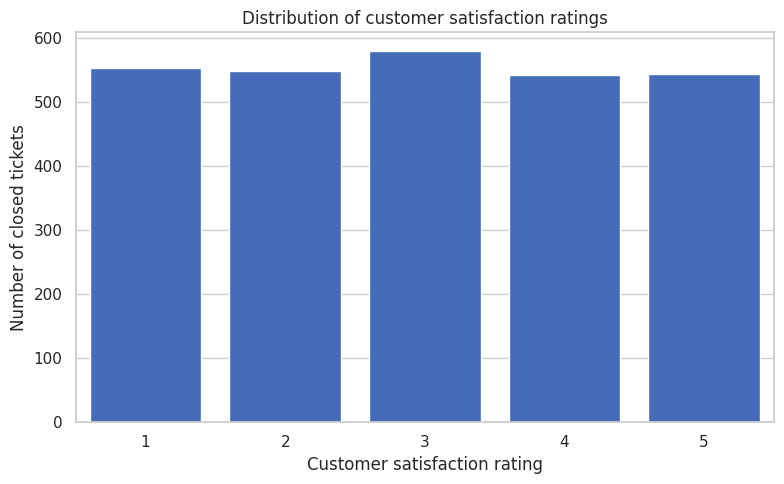

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rated_tickets,
    x=rating,
    order=[1, 2, 3, 4, 5],
    color="#3366CC"
)

plt.title("Distribution of customer satisfaction ratings")
plt.xlabel("Customer satisfaction rating")
plt.ylabel("Number of closed tickets")
plt.tight_layout()
plt.show()

In [9]:
observed = (
    rated_tickets[rating]
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
)

expected = np.repeat(
    observed.sum() / 5,
    5
)

chi_square, p_value = chi2_contingency(
    [observed, expected]
)[:2]

print(f"Chi-squared statistic: {chi_square:.3f}")
print(f"p-value: {p_value:.4f}")

Chi-squared statistic: 0.821
p-value: 0.9356


In [10]:
observed = (
    rated_tickets[rating]
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
)

expected = np.repeat(
    observed.sum() / 5,
    5
)

chi_square, p_value = chi2_contingency(
    [observed, expected]
)[:2]

print(f"Chi-squared statistic: {chi_square:.3f}")
print(f"p-value: {p_value:.4f}")

Chi-squared statistic: 0.821
p-value: 0.9356


In [11]:
categorical_factors = [
    "Ticket Type",
    "Ticket Priority",
    "Ticket Channel",
    "Product Purchased",
    "Customer Gender"
]

In [12]:
grouped_results = []

for factor in categorical_factors:

    summary = (
        rated_tickets
        .groupby(factor)[rating]
        .agg(
            Count="count",
            Mean="mean",
            Median="median",
            Standard_Deviation="std"
        )
        .reset_index()
    )

    summary["Factor"] = factor
    summary = summary.rename(columns={factor: "Group"})

    grouped_results.append(summary)

grouped_summary = pd.concat(
    grouped_results,
    ignore_index=True
)

grouped_summary.round(3)

,Group,Count,Mean,Median,Standard_Deviation,Factor
0,Billing inquiry,544,3.028,3.0,1.404,Ticket Type
1,Cancellation request,516,3.029,3.0,1.434,Ticket Type
2,Product inquiry,533,3.017,3.0,1.366,Ticket Type
3,Refund request,596,2.935,3.0,1.427,Ticket Type
4,Technical issue,580,2.959,3.0,1.404,Ticket Type
5,Critical,726,2.959,3.0,1.417,Ticket Priority
6,High,705,2.983,3.0,1.435,Ticket Priority
7,Low,644,3.053,3.0,1.394,Ticket Priority
8,Medium,694,2.977,3.0,1.381,Ticket Priority
9,Chat,674,3.083,3.0,1.408,Ticket Channel


In [14]:
def plot_rating_distribution(data, factor):

    proportions = pd.crosstab(
        data[factor],
        data[rating],
        normalize="index"
    )

    proportions = proportions.reindex(
        columns=[1, 2, 3, 4, 5],
        fill_value=0
    )

    proportions.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6),
        colormap="RdYlGn"
    )

    plt.title(f"Customer ratings by {factor.lower()}")
    plt.xlabel(factor)
    plt.ylabel("Proportion of tickets")
    plt.legend(
        title="Rating",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

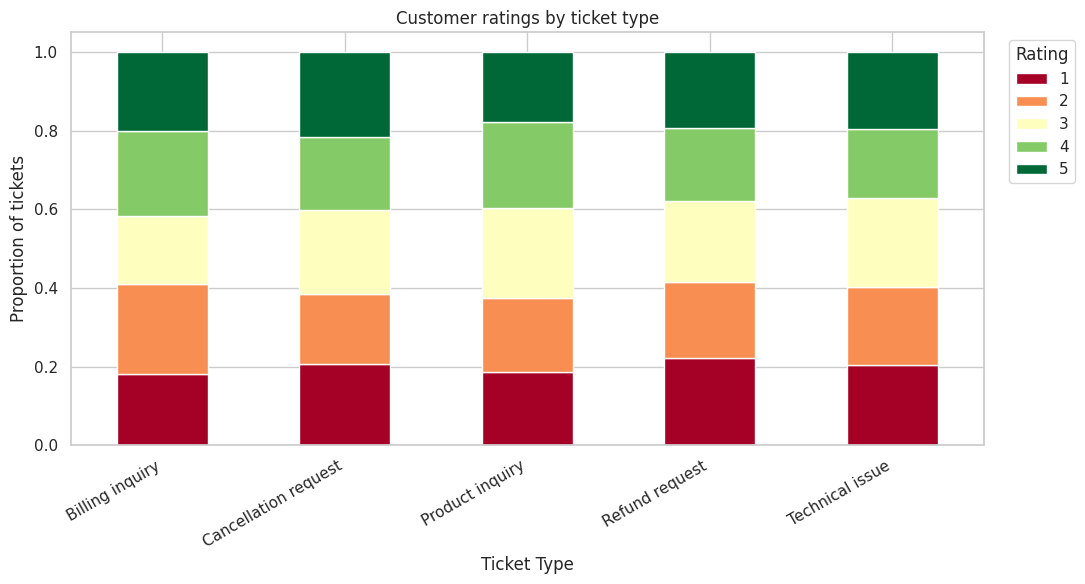

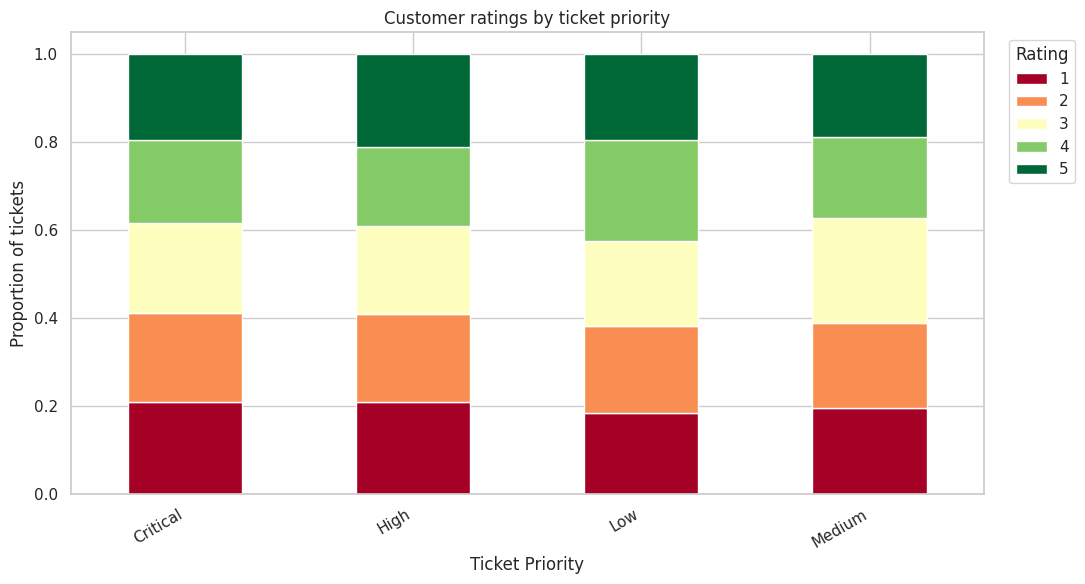

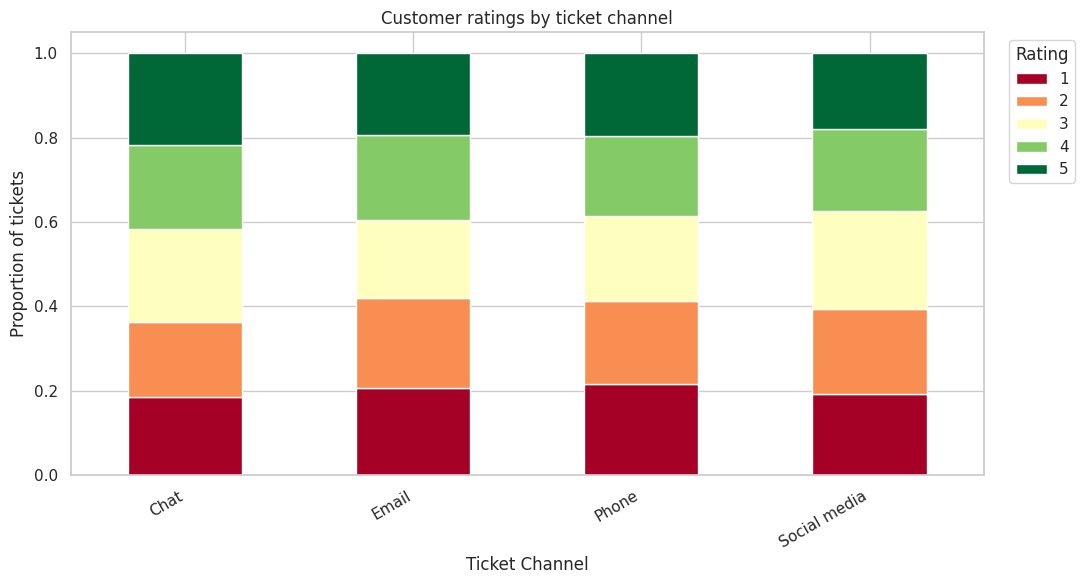

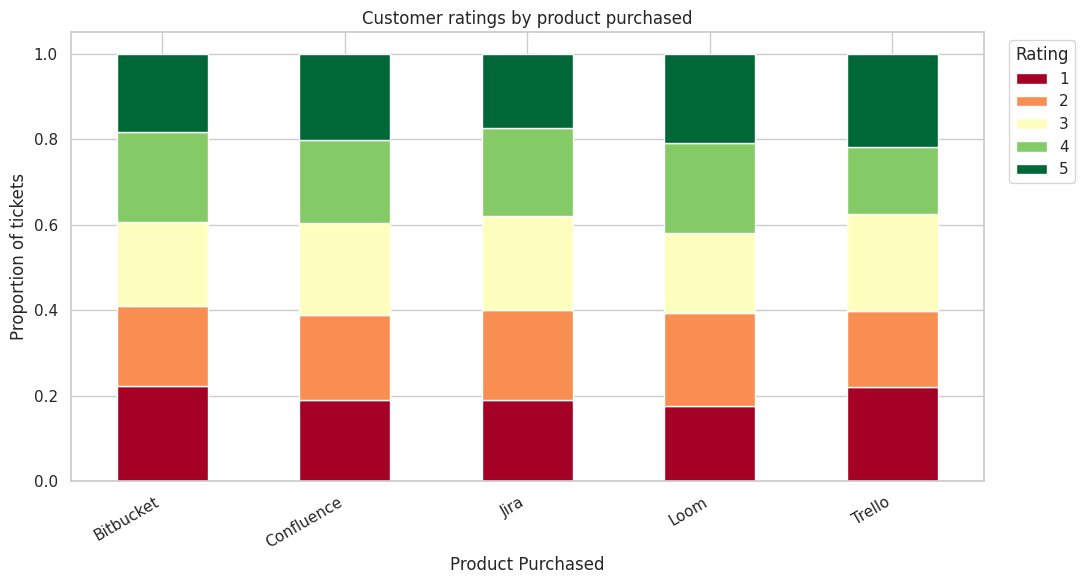

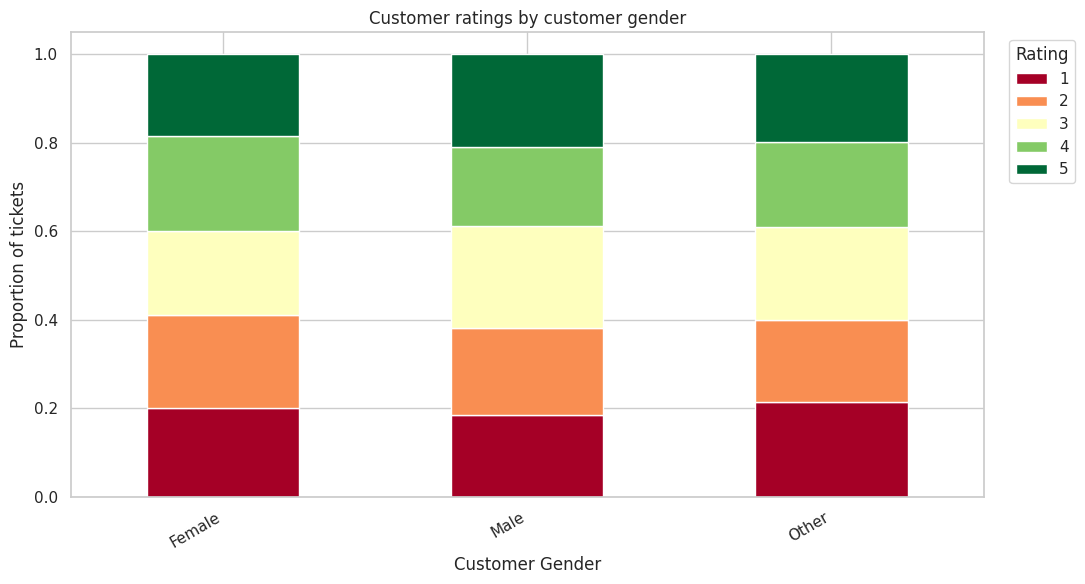

In [15]:
for factor in categorical_factors:
    plot_rating_distribution(rated_tickets, factor)

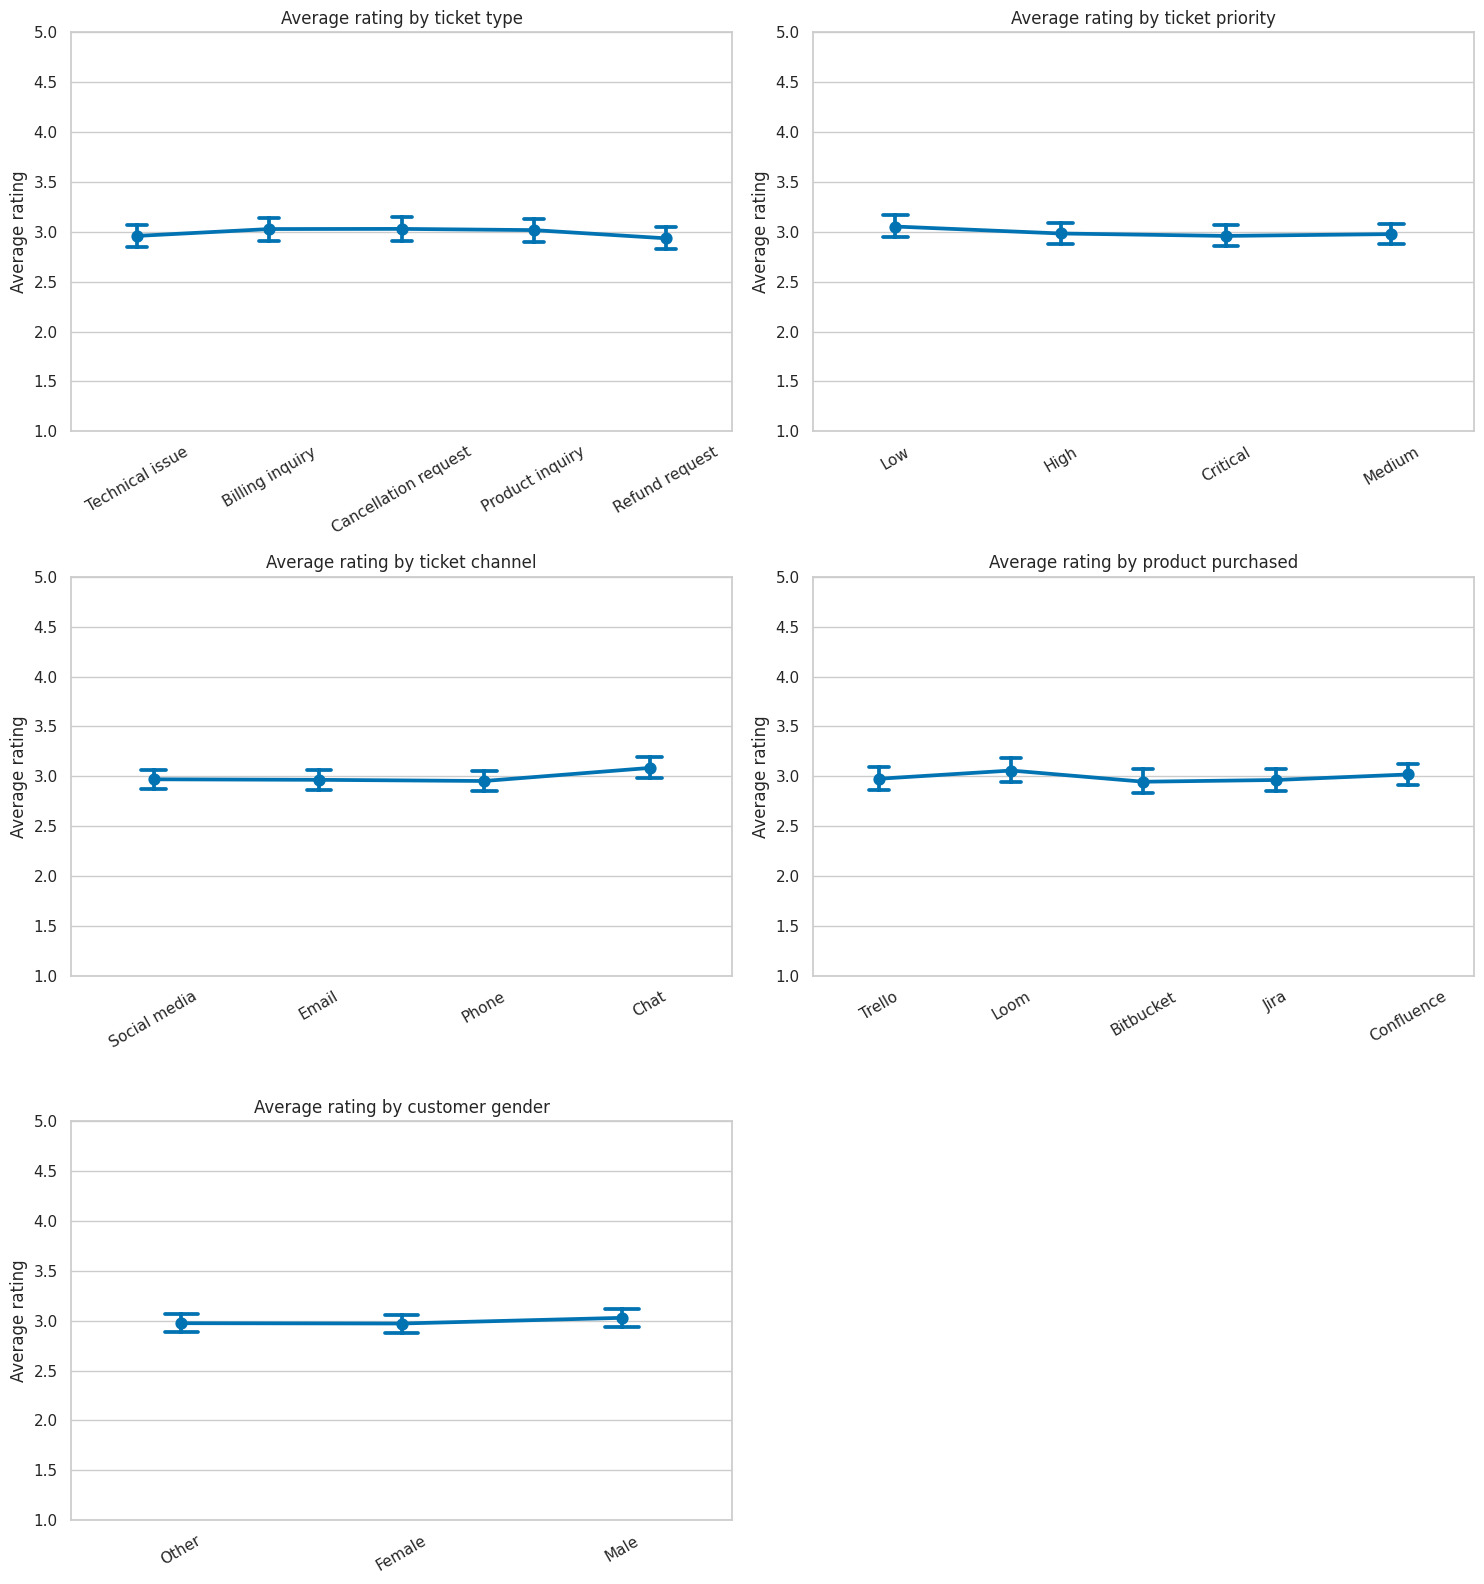

In [16]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(15, 16)
)

axes = axes.flatten()

for ax, factor in zip(axes, categorical_factors):

    sns.pointplot(
        data=rated_tickets,
        x=factor,
        y=rating,
        errorbar=("ci", 95),
        capsize=0.15,
        ax=ax
    )

    ax.set_title(f"Average rating by {factor.lower()}")
    ax.set_xlabel("")
    ax.set_ylabel("Average rating")
    ax.set_ylim(1, 5)
    ax.tick_params(axis="x", rotation=30)

# Remove unused subplot
for i in range(len(categorical_factors), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [18]:
def kruskal_by_factor(data, factor, outcome):

    groups = [
        group[outcome].dropna().values
        for _, group in data.groupby(factor)
    ]

    statistic, p_value = kruskal(*groups)

    return pd.Series({
        "Factor": factor,
        "Kruskal_Wallis_H": statistic,
        "p_value": p_value,
        "Number_of_groups": data[factor].nunique()
    })

In [19]:
kruskal_results = pd.DataFrame([
    kruskal_by_factor(
        rated_tickets,
        factor,
        rating
    )
    for factor in categorical_factors
])

# Adjust for multiple comparisons using Bonferroni
kruskal_results["Bonferroni_p"] = np.minimum(
    kruskal_results["p_value"]
    * len(categorical_factors),
    1
)

kruskal_results["Significant_after_adjustment"] = (
    kruskal_results["Bonferroni_p"] < 0.05
)

kruskal_results.round(4)

,Factor,Kruskal_Wallis_H,p_value,Number_of_groups,Bonferroni_p,Significant_after_adjustment
0,Ticket Type,2.1988,0.6993,5,1.0,False
1,Ticket Priority,1.7372,0.6287,4,1.0,False
2,Ticket Channel,3.8471,0.2785,4,1.0,False
3,Product Purchased,2.2645,0.6872,5,1.0,False
4,Customer Gender,0.9385,0.6255,3,1.0,False


In [41]:
datetime_columns = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]

for column in datetime_columns:
    rated_tickets[column] = pd.to_datetime(
        rated_tickets[column],
        dayfirst=True,
        errors="coerce"
    )

In [42]:
rated_tickets["Resolution Hours"] = (
    rated_tickets["Time to Resolution"]
    - rated_tickets["First Response Time"]
).dt.total_seconds() / 3600

In [22]:
rated_tickets[
    ["First Response Time", "Time to Resolution", "Resolution Hours"]
].describe()

,First Response Time,Time to Resolution,Resolution Hours
count,2769,2769,2769.000000
mean,2023-06-01 11:20:19.458288128,2023-06-01 11:16:51.722643456,-0.057704
min,2023-05-31 21:55:00,2023-05-31 21:53:00,-23.233333
25%,2023-06-01 05:19:00,2023-06-01 05:34:00,-6.933333
50%,2023-06-01 11:22:00,2023-06-01 11:17:00,0.166667
75%,2023-06-01 17:27:00,2023-06-01 17:07:00,6.483333
max,2023-06-02 00:54:00,2023-06-02 00:55:00,23.466667
std,NaN,NaN,9.564112


In [23]:
print(
    "Negative resolution durations:",
    (rated_tickets["Resolution Hours"] < 0).sum()
)

Negative resolution durations: 1365


In [24]:
rated_tickets.loc[
    rated_tickets["Resolution Hours"] < 0,
    "Resolution Hours"
] = np.nan

In [25]:
numeric_variables = [
    "Customer Satisfaction Rating",
    "Customer Age",
    "Resolution Hours"
]

correlation_matrix = (
    rated_tickets[numeric_variables]
    .corr(method="spearman")
)

correlation_matrix.round(3)

,Customer Satisfaction Rating,Customer Age,Resolution Hours
Customer Satisfaction Rating,1.000,-0.004,0.003
Customer Age,-0.004,1.000,0.039
Resolution Hours,0.003,0.039,1.000


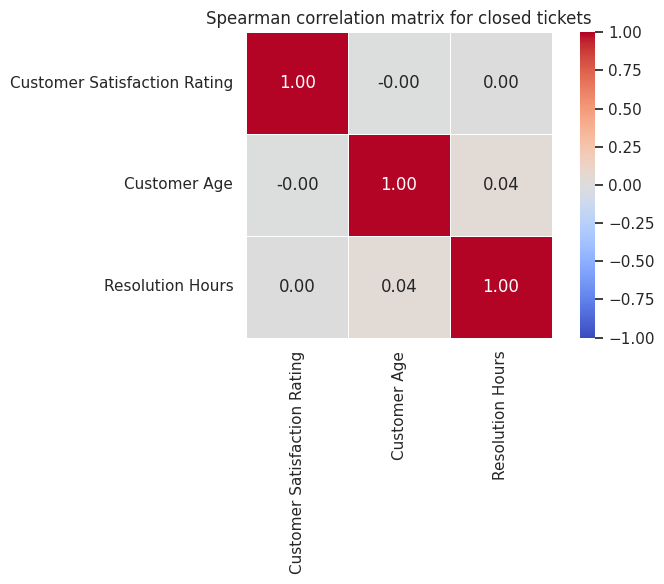

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Spearman correlation matrix for closed tickets")
plt.tight_layout()
plt.show()

In [27]:
def spearman_test(data, x, y):

    complete = data[[x, y]].dropna()

    rho, p_value = spearmanr(
        complete[x],
        complete[y]
    )

    return {
        "Variable": x,
        "Rating correlation": rho,
        "p-value": p_value,
        "Complete observations": len(complete)
    }

In [28]:
rating_correlations = pd.DataFrame([
    spearman_test(
        rated_tickets,
        "Customer Age",
        rating
    ),
    spearman_test(
        rated_tickets,
        "Resolution Hours",
        rating
    )
])

rating_correlations.round(4)

,Variable,Rating correlation,p-value,Complete observations
0,Customer Age,-0.0040,0.8315,2769
1,Resolution Hours,0.0026,0.9213,1404


**Trying to look at other differences - suggested by GPT **

In [29]:
# Difference between highest and lowest group mean
group_means = (
    rated_tickets
    .groupby("Ticket Channel")["Customer Satisfaction Rating"]
    .mean()
)

mean_range = group_means.max() - group_means.min()

print("Largest difference in group means:", round(mean_range, 3))

Largest difference in group means: 0.131


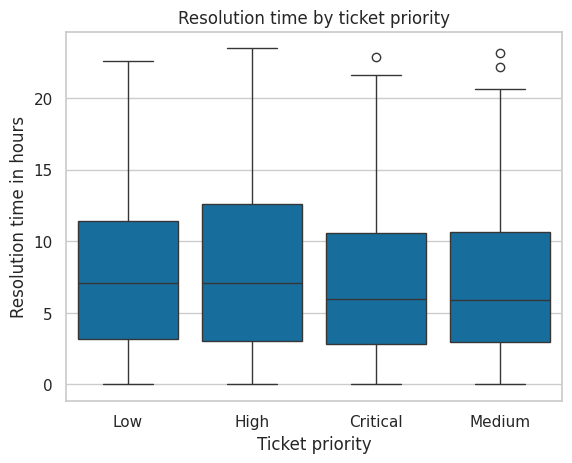

In [30]:
sns.boxplot(
    data=rated_tickets,
    x="Ticket Priority",
    y="Resolution Hours"
)

plt.title("Resolution time by ticket priority")
plt.xlabel("Ticket priority")
plt.ylabel("Resolution time in hours")
plt.show()

In [31]:
missingness_table = pd.crosstab(
    tickets["Ticket Status"],
    tickets["Customer Satisfaction Rating"].isna(),
    normalize="index"
)

missingness_table

Customer Satisfaction Rating,False,True
Ticket Status,,
Closed,1.0,0.0
Open,0.0,1.0
Pending Customer Response,0.0,1.0


NameError: name 'usage' is not defined

NameError: name 'usage' is not defined

NameError: name 'usage' is not defined

In [38]:
two_factor_summary = (
    rated_tickets
    .groupby(["Product Purchased", "Ticket Type"])
    .agg(
        mean_rating=(
            "Customer Satisfaction Rating",
            "mean"
        ),
        median_rating=(
            "Customer Satisfaction Rating",
            "median"
        ),
        sample_size=(
            "Customer Satisfaction Rating",
            "size"
        )
    )
    .reset_index()
)

two_factor_summary.head()

,Product Purchased,Ticket Type,mean_rating,median_rating,sample_size
0,Bitbucket,Billing inquiry,2.924731,3.0,93
1,Bitbucket,Cancellation request,3.109890,3.0,91
2,Bitbucket,Product inquiry,2.937500,3.0,96
3,Bitbucket,Refund request,2.896825,3.0,126
4,Bitbucket,Technical issue,2.892562,3.0,121


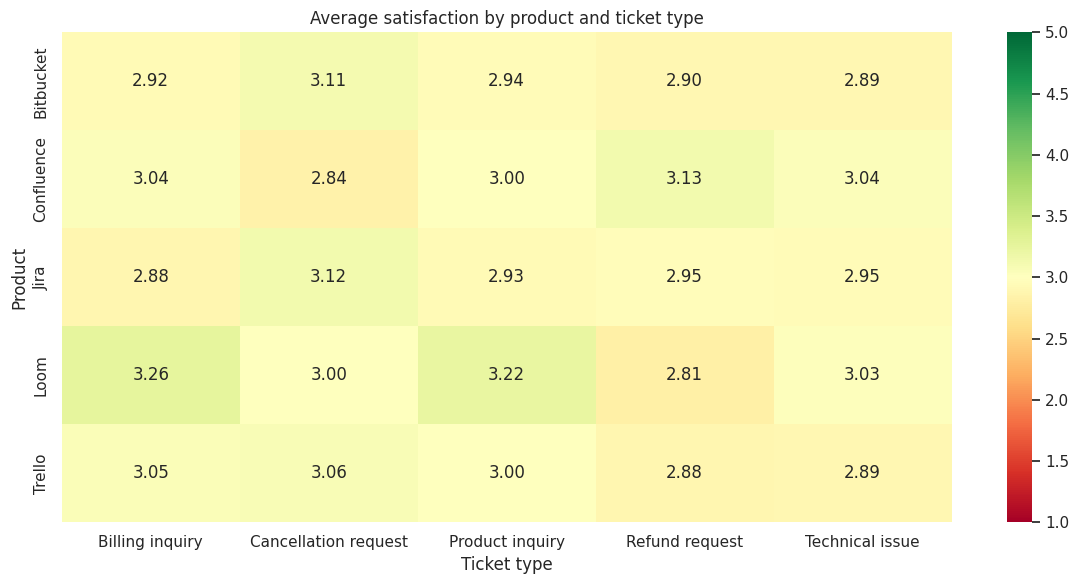

In [39]:
rating_heatmap = two_factor_summary.pivot(
    index="Product Purchased",
    columns="Ticket Type",
    values="mean_rating"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=1,
    vmax=5
)

plt.title("Average satisfaction by product and ticket type")
plt.xlabel("Ticket type")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

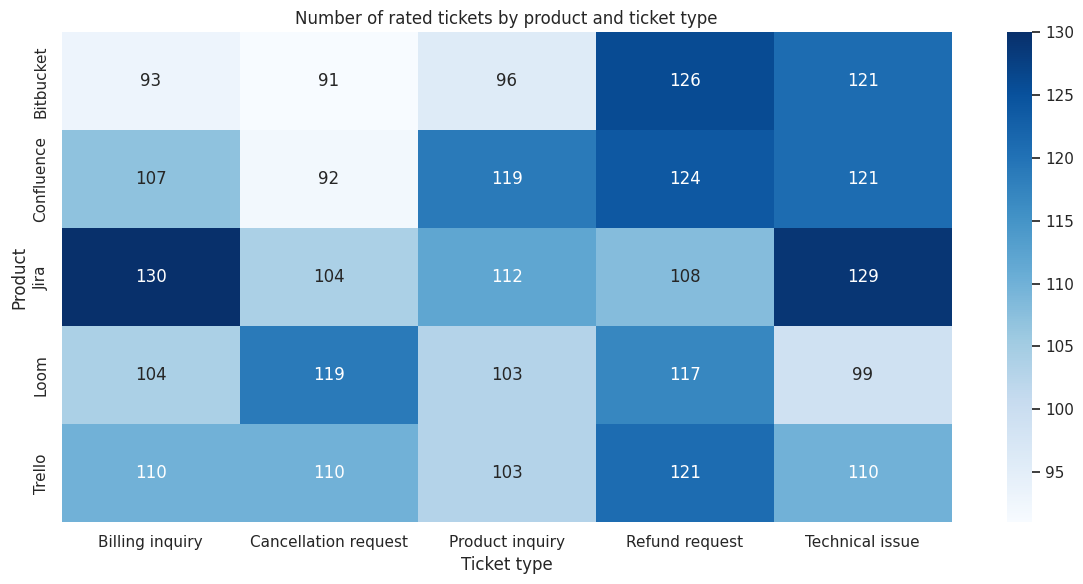

In [40]:
sample_heatmap = two_factor_summary.pivot(
    index="Product Purchased",
    columns="Ticket Type",
    values="sample_size"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    sample_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Number of rated tickets by product and ticket type")
plt.xlabel("Ticket type")
plt.ylabel("Product")
plt.tight_layout()
plt.show()